In [93]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [94]:
path = "../../data/ks_equation/multitraj_nu70/"

data_files = sorted(glob.glob(os.path.join(path, "data_nu*.npy")))

print(f"Number of trajectories found : {len(data_files)}")

trajectories = [np.load(f) for f in data_files]

print(f"Dimensions of a trajectory : {trajectories[0].shape}")

Number of trajectories found : 10
Dimensions of a trajectory : (1024, 2001)


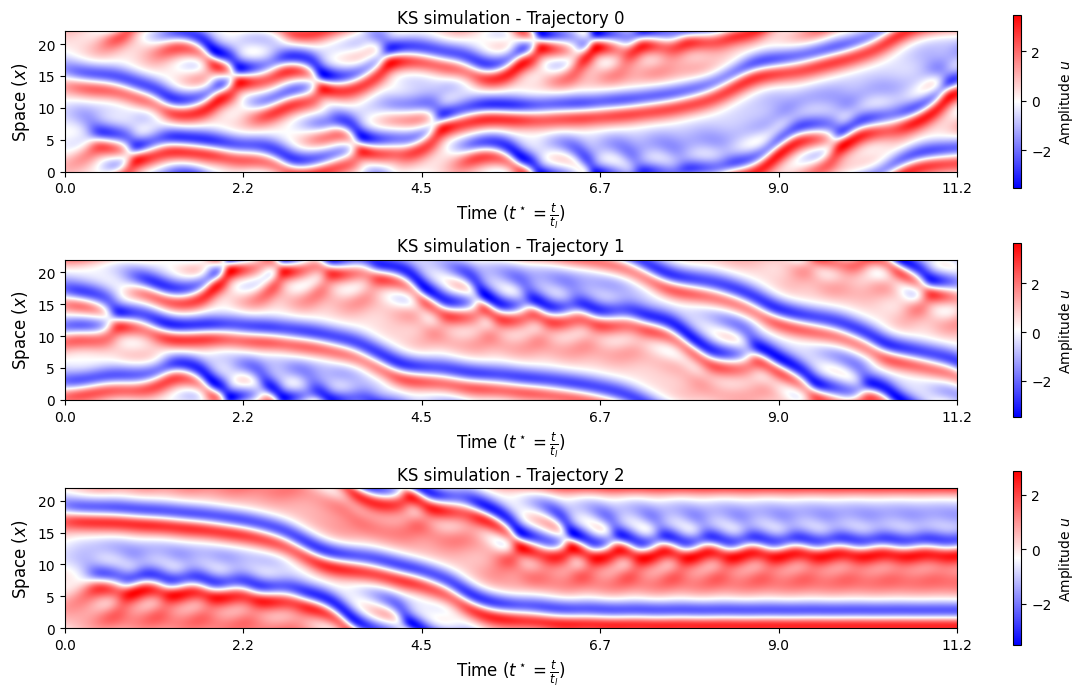

In [104]:
T = 150
L = 22.
tl = 12.478292398441297
discard = 10.

def plot_trajectories(traj_list, n_plots=3):
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 7))
    
    if n_plots == 1: axes = [axes]

    for i in range(min(n_plots, len(traj_list))):

        nT = traj_list[i].shape[1]
        nt_start = int(discard/T*nT)
        Tf = T - discard
        u = traj_list[3+i][:,nt_start:]
   
        im = axes[i].imshow(u, aspect='1', cmap='bwr', 
                            extent=[0, Tf, 0, 22],
                            origin='lower') 
        
        axes[i].set_title(f"KS simulation - Trajectory {i}")
        axes[i].set_xlabel(r"Time ($t^\star = \frac{t}{t_l}$)", fontsize=12)
        axes[i].set_ylabel("Space ($x$)", fontsize=12)
        xticks = np.linspace(0, Tf, 6)
        axes[i].set_xticks(xticks)
        axes[i].set_xticklabels([f"{x/tl:.1f}" for x in xticks])
        plt.colorbar(im, ax=axes[i], label="Amplitude $u$")

    plt.tight_layout()
    plt.show()

plot_trajectories(trajectories)

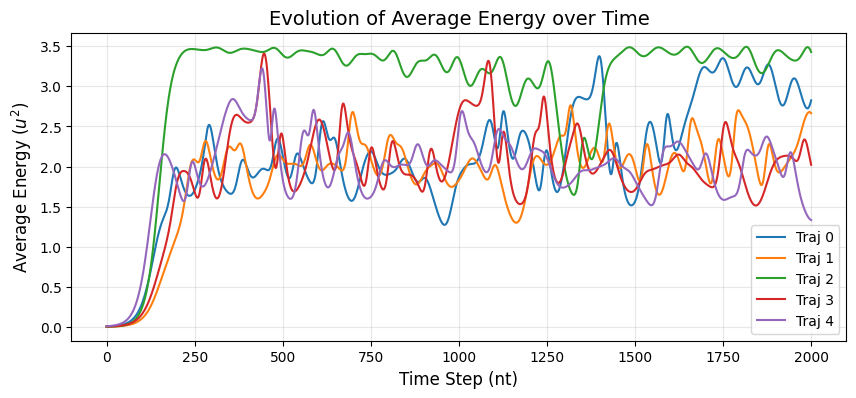

In [96]:
plt.figure(figsize=(10, 4))

for i, u in enumerate(trajectories[:5]): # Analyse des 5 premières
    
    energy = np.mean(u**2, axis=0)
    plt.plot(energy, label=f"Traj {i}")

plt.title("Evolution of Average Energy over Time", fontsize=14)
plt.xlabel("Time Step (nt)", fontsize=12)
plt.ylabel("Average Energy ($u^2$)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

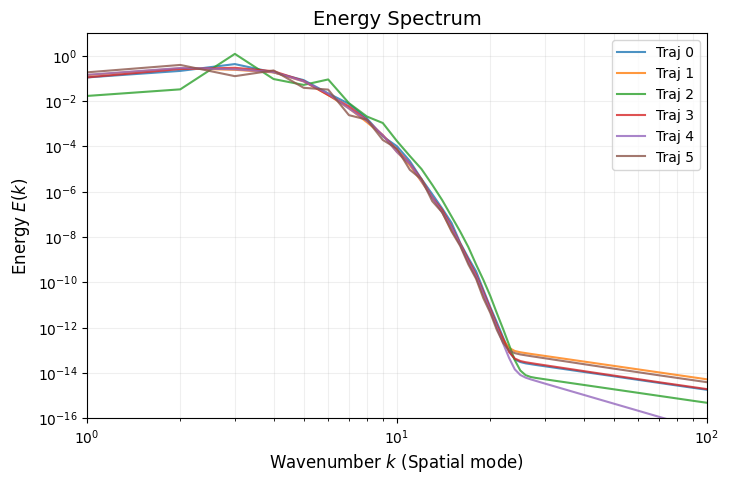

In [97]:
def energy_spectrum(u):

    nx, nt = u.shape 
    u_norm = u - np.mean(u, axis=0, keepdims=True)

    fft_u = np.fft.rfft(u_norm, axis=0)
    
    E_hat = np.mean(np.abs(fft_u)**2, axis=1) / (nx**2)

    kx = np.fft.rfftfreq(nx, d=1.0) * nx
    mask = E_hat > 0
    return E_hat[mask], kx[mask]


plt.figure(figsize=(8, 5))

for i in range(6):
    E_k, k = energy_spectrum(trajectories[i])

    plt.loglog(k[1:], E_k[1:], label=f"Traj {i}", alpha=0.8)

plt.title("Energy Spectrum", fontsize=14)
plt.xlabel("Wavenumber $k$ (Spatial mode)", fontsize=12)
plt.ylabel("Energy $E(k)$", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(1, 100)
plt.ylim(1e-16, 1e1)
plt.legend()
plt.show()

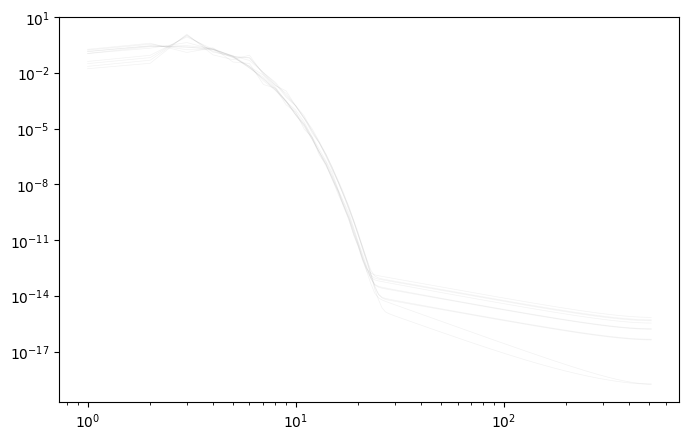

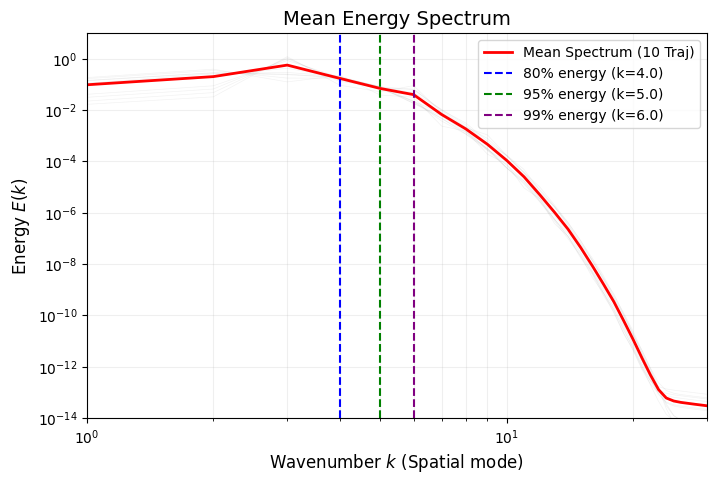

In [98]:
def energy_spectrum(u):
    nx, nt = u.shape 
    u_norm = u - np.mean(u, axis=0, keepdims=True)
    fft_u = np.fft.rfft(u_norm, axis=0)
    E_hat = np.mean(np.abs(fft_u)**2, axis=1) / (nx**2)
    kx = np.fft.rfftfreq(nx, d=1.0) * nx
    mask = E_hat > 0
    return E_hat[mask], kx[mask]

# --- Adapted Code for Mean Spectrum ---

plt.figure(figsize=(8, 5))

all_E_k = []
k_shared = None

for i in range(10):
    E_k, k = energy_spectrum(trajectories[i])
    all_E_k.append(E_k)
    k_shared = k 

mean_E_k = np.mean(all_E_k, axis=0)

for E_k in all_E_k:
    plt.loglog(k_shared[1:], E_k[1:], color='gray', alpha=0.1, lw=0.5)


cumulative_energy = np.cumsum(mean_E_k)
total_energy = cumulative_energy[-1]
cumulative_energy /= total_energy  # normalize to [0,1]


thresholds = [0.8, 0.95, 0.99]
k_thresholds = []

for t in thresholds:
    idx = np.searchsorted(cumulative_energy, t)
    k_thresholds.append(k_shared[idx])

# --- Plot ---
plt.figure(figsize=(8, 5))

for E_k in all_E_k:
    plt.loglog(k_shared[1:], E_k[1:], color='gray', alpha=0.1, lw=0.5)

plt.loglog(k_shared[1:], mean_E_k[1:], color='red', lw=2, label="Mean Spectrum (10 Traj)")


colors = ['blue', 'green', 'purple']
labels = ['80%', '95%', '99%']

for k_val, c, lab in zip(k_thresholds, colors, labels):
    plt.axvline(k_val, linestyle='--', color=c, label=f"{lab} energy (k={k_val:.1f})")

plt.title("Mean Energy Spectrum", fontsize=14)
plt.xlabel("Wavenumber $k$ (Spatial mode)", fontsize=12)
plt.ylabel("Energy $E(k)$", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(1, 30)
plt.ylim(1e-14, 1e1)
plt.legend()
plt.show()

Lyapunov exponents (largest → smallest):
[ 0.00823621  0.0027161   0.00103145 -0.000476   -0.00580766 -0.01967853
 -0.02902063 -0.03318865 -0.03930067 -0.04028556]


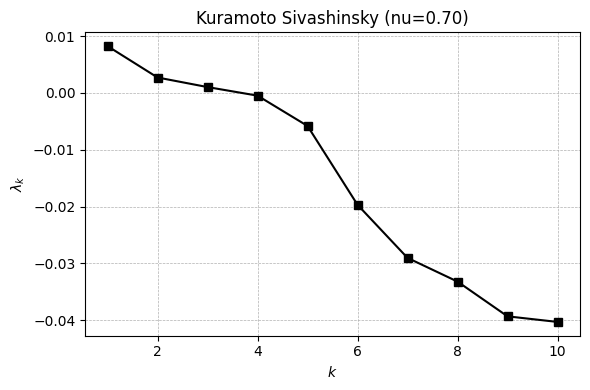

In [72]:
def wavenumbers(Mx, L):
    return np.fft.rfftfreq(Mx, L/2/np.pi/Mx)

def _freq_squared(u_hat):
    ureal = np.fft.irfft(u_hat)
    usp = np.fft.rfft(ureal.real * ureal.real)
    return usp

class KSIntegrator:

    def __init__(self, Mx, L, nu, dt):
        self.Mx, self.L, self.nu, self.dt = Mx, L, nu, dt
        self.kx = wavenumbers(Mx, L)
        self.k2 = -(self.kx**2) + nu*(self.kx**4)
        self.A = 1.0
        self.n_modes = self.k2.shape[0]



    def _project_zero_modes(self, u_hat):
        # enforce zero-mean and zero Nyquist
        u_hat = u_hat.copy()
        u_hat[0] = 0.0
        u_hat[-1] = 0.0
        return u_hat

    def advance_segment(self, u0, steps):
        """
        Advance from u0 for 'steps' time steps of size dt.
        Returns the final state u_end (real space) and the whole history if needed.
        """
        dt = self.dt
        Mx = self.Mx
        u_hat_hist = np.empty((self.n_modes, max(3, steps+1)), dtype=np.complex128)
        u_hist = np.empty((Mx, max(3, steps+1)), dtype=np.float64)
        nlin_term = np.empty_like(u_hat_hist)
        # t=0
        u_hist[:, 0] = u0
        u_hat_hist[:, 0] = np.fft.rfft(u0)
        u_hat_hist[:, 0] = self._project_zero_modes(u_hat_hist[:, 0])
        usqr_hat0 = _freq_squared(u_hat_hist[:, 0])
        nlin_term[:, 0] = -0.5j * self.kx * usqr_hat0
        # i = 0
        us0 = (u_hat_hist[:, 0] + dt*nlin_term[:, 0]) / (self.A + dt*self.k2)
        us0 = self._project_zero_modes(us0)
        nls_mid = _freq_squared(0.5*(u_hat_hist[:, 0] + us0))
        nlspec = -0.5j*self.kx*nls_mid
        u_hat_hist[:, 1] = (u_hat_hist[:, 0] - 0.5*dt*self.k2*u_hat_hist[:, 0] + dt*nlspec) / (self.A + 0.5*dt*self.k2)
        u_hat_hist[:, 1] = self._project_zero_modes(u_hat_hist[:, 1])
        u_hist[:, 1] = np.fft.irfft(u_hat_hist[:, 1], n=Mx)
        if steps == 1:
            return u_hist[:, 1], (u_hist[:, :2], u_hat_hist[:, :2])
        # i = 1
        usqr_hat1 = _freq_squared(u_hat_hist[:, 1])
        nlin_term[:, 1] = -0.5j*self.kx*usqr_hat1
        u_hat_hist[:, 2] = ((4*u_hat_hist[:, 1]) - u_hat_hist[:, 0] + (4*dt*nlin_term[:, 1]) - (2*dt*nlin_term[:, 0])) / (3*self.A + 2*dt*self.k2)
        u_hat_hist[:, 2] = self._project_zero_modes(u_hat_hist[:, 2])
        u_hist[:, 2] = np.fft.irfft(u_hat_hist[:, 2], n=Mx)
        if steps == 2:
            return u_hist[:, 2], (u_hist[:, :3], u_hat_hist[:, :3])
        # main loop
        last_index = 2
        for i in range(2, steps):
            usqr_hat_i = _freq_squared(u_hat_hist[:, last_index])
            usqr_hat_im1 = _freq_squared(u_hat_hist[:, last_index-1])
            usqr_hat_im2 = _freq_squared(u_hat_hist[:, last_index-2])
            nlin_i = -0.5j*self.kx*usqr_hat_i
            nlin_im1 = -0.5j*self.kx*usqr_hat_im1
            nlin_im2 = -0.5j*self.kx*usqr_hat_im2
            u_next = ((18*u_hat_hist[:, last_index]) - 9*u_hat_hist[:, last_index-1] + 2*u_hat_hist[:, last_index-2] + 18*dt*nlin_i - 18*dt*nlin_im1 + 6*dt*nlin_im2) / (11*self.A + 6*dt*self.k2)
            u_next = self._project_zero_modes(u_next)
            u_hat_hist[:, last_index+1] = u_next
            u_hist[:, last_index+1] = np.fft.irfft(u_next, n=Mx)
            last_index += 1
            return u_hist[:, last_index], (u_hist[:, :last_index+1], u_hat_hist[:, :last_index+1])

# ----------------------------------------------------------
# Benettin/Wolf Lyapunov spectrum using the segment integrator
# ----------------------------------------------------------

def _orthonormal_basis(Mx, k, rng):
    """
    Build k zero-mean orthonormal vectors in R^Mx (L2 inner product in real space).
    """
    V = rng.normal(size=(Mx, k))
    # enforce zero mean (to avoid exciting the removed k=0 mode)
    V -= V.mean(axis=0, keepdims=True)
    # Classical Gram–Schmidt
    Q = np.zeros_like(V)
    for j in range(k):
        v = V[:, j].copy()
        for i in range(j):
            v -= np.dot(Q[:, i], v) * Q[:, i]
        nrm = np.linalg.norm(v)
        if nrm < 1e-14: # very unlikely; regenerat
            v = rng.normal(size=Mx); v -= v.mean()
            nrm = np.linalg.norm(v)
        Q[:, j] = v / nrm
    return Q

def lyapunov_spectrum_ks(u0,
                         Mx,
                         L,
                         nu,
                         dt,
                         k=10,
                         steps_per_cycle=50,
                         n_cycles=200,
                         eps=1e-8,
                         seed=0,
                         return_traces=False,
                         ):
    """
    Compute the first k Lyapunov exponents for the KS solver using the Benettin/Wolf method.
    Parameters
    ----------
    u0 : array, shape (Mx,) 
        Initial condition in real space.    Mx, L, nu, dt : as in your solver.
    k : int
        Number of exponents to compute (k <= Mx).
    steps_per_cycle : int
        Integrator steps between QR re-orthonormalizations.
    n_cycles : int
        Number of QR cycles to average over.
    eps : float
        Perturbation size.
    seed : int
        RNG seed for initial perturbation basis.
    return_traces : bool
        If True, also return cumulative sums and instantaneous norms per cycle.
    Returns
    -------
    lambdas : array, shape (k,)
        Estimated Lyapunov exponents (1/time units), sorted from largest to smallest.
    info : dict
        Diagnostics: {'sum_logs': ..., 'avg_dt': dt, 'T_total': steps_per_cycle*n_cycles*dt, ...}
    """
    rng = np.random.default_rng(seed)
    integ = KSIntegrator(Mx, L, nu, dt)
    # make sure baseline is zero-mean compatible with spectral projection
    u_base = u0 - u0.mean()
    # initial orthonormal bundle (in real space)
    Q = _orthonormal_basis(Mx, k, rng)
    # accumulators
    sum_logs = np.zeros(k) # sum of log(R_ii)
    norms_history = [] # optional, per-cycle diag(R)
    t_total = 0.0
    for cyc in range(n_cycles):
        # Evolve baseline over one cycle
        u_base_end, _ = integ.advance_segment(u_base, steps_per_cycle)
        # Evolve each perturbed trajectory over the same window
        diffs = np.empty((Mx, k))
        for j in range(k):
            u_pert0 = u_base + eps * Q[:, j]
            u_pert0 -= u_pert0.mean() # keep zero-mean
            u_pert_end, _ = integ.advance_segment(u_pert0, steps_per_cycle)
            diffs[:, j] = (u_pert_end - u_base_end) / eps
        # QR re-orthonormalization in real space
        # We use numpy.linalg.qr with 'reduced' mode; R has positive diagonals if we flip signs accordingly.
        Q_new, R = np.linalg.qr(diffs, mode='reduced')
        # Ensure positive diagonals for a consistent log accumulation
        diag_R = np.diag(R).copy()
        signs = np.sign(diag_R)
        signs[signs == 0.0] = 1.0
        Q_new = Q_new * signs
        diag_R = np.abs(diag_R)
        sum_logs += np.log(diag_R + 1e-300) # avoid log(0)
        if return_traces:
            norms_history.append(diag_R)
        # Prepare for next cycle
        Q = Q_new
        u_base = u_base_end
        t_total += steps_per_cycle * dt
    lambdas = sum_logs / t_total
    info = {
        "sum_logs": sum_logs,
        "avg_dt": dt,
        "T_total": t_total,
        "steps_per_cycle": steps_per_cycle,
        "n_cycles": n_cycles,
        "eps": eps,
        }
    if return_traces:
        info["diagR_history"] = np.array(norms_history)
    return lambdas, info

# -------------------------
# Simple demo when run alone
# -------------------------

if __name__ == "__main__":
    # Example parameters
    nt = 10000
    L = 22.0
    nu = 0.7
    Mx = 1024
    Tf = 2500
    dt = Tf / nt
    # initial condition
    x = np.linspace(0, L, Mx)

    # Initial condition: sum of cosines + small perturbation
    # u0 = 0.06*(np.cos(2*PI*x/L) + np.cos(2*2*PI*x/L) + np.cos(3*2*PI*x/L) + np.cos(4*2*PI*x/L))
    # u0[0] += 1e-5

    # Or: cosine base + noise    
    # # base = 0.06*(np.cos(2*np.pi*x/L) + np.cos(2*2*np.pi*x/L))    # noise = 0.005 * np.fft.irfft((np.random.randn(Mx//2+1) + 1j*np.random.randn(Mx//2+1)))   # u0 = base + noise

    def init_u_rand(x, L, Mx):
        """Randomized initial condition (cos base + small spectral noise)."""
        base = 0.06*(np.cos(2*np.pi*x/L) + np.cos(2*2*np.pi*x/L))
        noise = 0.005 * np.fft.irfft((np.random.randn(Mx//2+1) + 1j*np.random.randn(Mx//2+1)))
        return base + noise

    # Or: pure noise
    # sigma = 0.1
    # noise_spectral = (np.random.randn(Mx//2 + 1) + 1j * np.random.randn(Mx//2 + 1))
    # noise_real = np.fft.irfft(noise_spectral, n=Mx)
    # noise_real *= sigma / np.std(noise_real)
    # u0 = noise_real

    u0 = init_u_rand(x, L, Mx)

    # compute first 10 exponents
    lambdas, info = lyapunov_spectrum_ks(
        u0, Mx, L, nu, dt,
        k=10,
        steps_per_cycle=50,
        n_cycles=200,
        eps=1e-8,
        seed=1,
        return_traces=False
        )
    print("Lyapunov exponents (largest → smallest):")
    print(lambdas)
    # plot
    ks = np.arange(1, 10+1)
    plt.figure(figsize=(6,4))
    plt.plot(ks, lambdas, 'ks-', label='KS LEs')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$\lambda_k$')
    plt.title(f'Kuramoto Sivashinsky (nu={nu:.2f})')
    plt.grid(ls='--', lw=0.5)
    plt.tight_layout()
    plt.show()

In [105]:
1/lambdas.max()

np.float64(121.41500823172757)

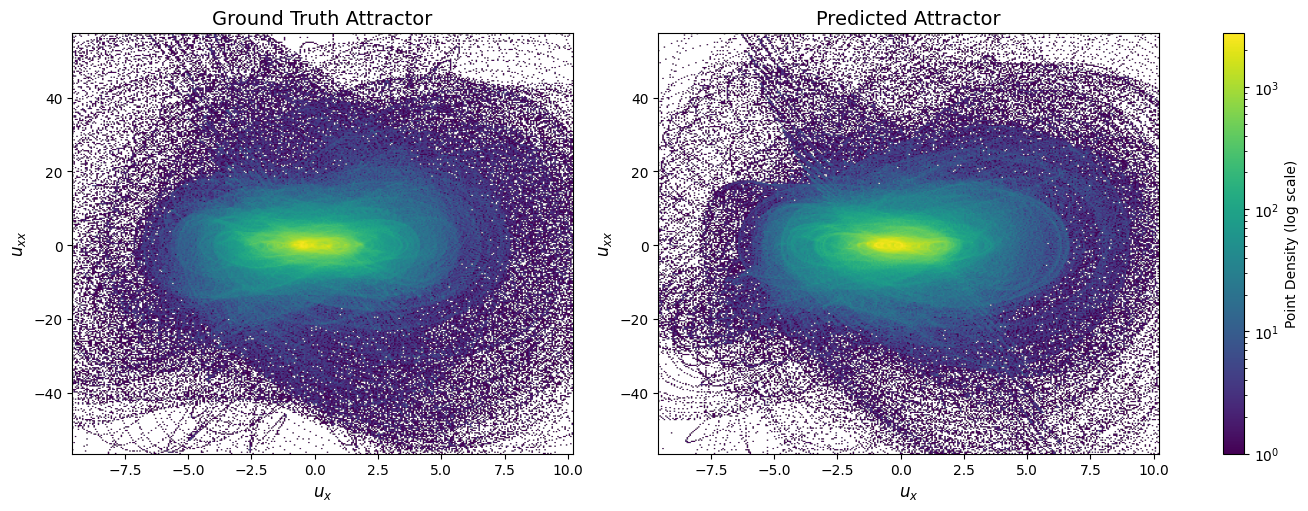

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def compute_spectral_derivatives(u, L):
    """
    Computes first and second spatial derivatives using FFT.
    u: 2D array (Time, Space)
    L: Domain length
    """
    u = np.asarray(u)
    nt, nx = u.shape

    # Calculate wavenumbers (2*pi*f)
    k = 2 * np.pi * np.fft.fftfreq(nx, d=L/nx)
    ik = 1j * k
    k2 = k**2

    # Fourier Transform along the spatial axis (axis=1)
    U_hat = np.fft.fft(u, axis=1)

    # Compute derivatives in Fourier space and transform back
    ux = np.fft.ifft(ik * U_hat, axis=1).real
    uxx = np.fft.ifft(-k2 * U_hat, axis=1).real

    return ux, uxx

def plot_attractor_density(u, L, ax, bins=350, xlim=None, ylim=None, log_density=True, title=None):
    """
    Generates a 2D histogram (phase portrait density) of ux vs uxx.
    """
    ux, uxx = compute_spectral_derivatives(u, L)
    
    # Flatten arrays for histogramming
    x_data = ux.ravel()
    y_data = uxx.ravel()

    # Determine limits based on percentiles if not provided
    if xlim is None:
        xlim = (np.percentile(x_data, 0.5), np.percentile(x_data, 99.5))
    if ylim is None:
        ylim = (np.percentile(y_data, 0.5), np.percentile(y_data, 99.5))

    # Compute 2D Histogram
    hist, x_edges, y_edges = np.histogram2d(x_data, y_data, bins=bins, range=[xlim, ylim])

    # Plotting configuration
    norm = LogNorm(vmin=1, vmax=hist.max()) if log_density else None
    
    im = ax.imshow(
        hist.T, origin="lower", 
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], 
        aspect="auto", cmap="viridis", norm=norm
    )

    ax.set_xlabel(r"$u_x$", fontsize=12)
    ax.set_ylabel(r"$u_{xx}$", fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)
    
    return im

# --- Main Execution ---

# Setup parameters
L = 32.0
limit = 2500
pred_data = trajectories[1]
true_data = trajectories[3]

# Global limits based on "True" data to ensure identical scales for comparison
ux_ref, uxx_ref = compute_spectral_derivatives(true_data, L)
shared_xlim = (np.percentile(ux_ref, 0.5), np.percentile(ux_ref, 99.5))
shared_ylim = (np.percentile(uxx_ref, 0.5), np.percentile(uxx_ref, 99.5))

# Create Figure
fig, (ax_true, ax_pred) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Plot True Data
im_true = plot_attractor_density(
    true_data, L, ax_true, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Ground Truth Attractor"
)

# Plot Predicted Data
im_pred = plot_attractor_density(
    pred_data, L, ax_pred, 
    xlim=shared_xlim, ylim=shared_ylim, 
    title="Predicted Attractor"
)

# Shared Colorbar
fig.colorbar(im_true, ax=[ax_true, ax_pred], label="Point Density (log scale)")

plt.show()